<div style="background:linear-gradient(135deg, rgba(249,112,102,0.18), rgba(249,112,102,0.02)); border-left:6px solid #F97066; border-radius:10px; padding:20px 24px; margin-bottom:20px;">
<h1 style="margin:0; color:#F97066; font-size:1.8em;">👁️ Visión por Computadora</h1>
<p style="margin:6px 0 0; opacity:0.8;">Unidad 4 — Cómo representa y transforma imágenes una computadora: píxeles, canales, convolución y filtrado</p>
</div>

En <code>1-fundamentos-redes-neuronales.ipynb</code> se presentó cómo se entrena una red neuronal en general. Antes de dar el siguiente paso hacia las redes neuronales convolucionales (CNN) de <code>3-redes-convolucionales.ipynb</code>, conviene entender cómo se representa una imagen dentro de una computadora — como una matriz de números — y qué es, exactamente, una convolución: la misma operación matemática que da nombre a las CNN.

<div style="border:1px solid rgba(14,165,233,0.35); border-radius:10px; padding:14px 20px; margin:16px 0 24px; background:rgba(14,165,233,0.04);">
<strong>📑 Contenido de esta guía</strong>
<ol style="margin:8px 0 0; padding-left:20px;">
<li><a href="#conceptos-basicos">Conceptos básicos de imágenes</a></li>
<li><a href="#filtrado">Filtrado de imágenes</a></li>
<li><a href="#deteccion-bordes">Detección de bordes: Sobel y Canny</a></li>
<li><a href="#binarizacion">Binarización y umbral de Otsu</a></li>
<li><a href="#cierre">Cierre y próximos pasos</a></li>
</ol>
</div>

<a id="conceptos-basicos"></a>

## <span style="color:#F97066;">Conceptos básicos de imágenes</span>

La visión por computadora es un campo científico interdisciplinario que se ocupa de cómo las computadoras pueden obtener una comprensión de alto nivel a partir de imágenes o videos digitales. Desde la perspectiva de la ingeniería, busca comprender y automatizar tareas que el sistema visual humano realiza de forma natural.

Una imagen es una digitalización del mundo real. Cada imagen consta de píxeles, pequeños cuadrados que contienen un color.

![Zoom sobre un píxel de una flor, con su valor RGB (230, 138, 57)](assets/cv-img-01.png)

*Al acercarse lo suficiente, una fotografía deja de verse como una escena continua y se revela como una cuadrícula de píxeles; cada uno almacena un color mediante tres números (rojo, verde, azul).*

![Fotografía de un venado con una región ampliada que muestra el efecto de pixelación](assets/cv-img-02.png)

*El mismo efecto sobre una fotografía completa: al ampliar una región pequeña se distinguen los píxeles individuales que la componen.*

Así se ve una imagen digital para las personas. Pero, ¿cómo la "ve" una computadora? ¿Qué recibe y cómo la procesa? Para una computadora, una imagen es una función bidimensional $f(x, y)$, donde $x$ y $y$ son coordenadas espaciales y la amplitud de $f$ en cualquier par de coordenadas $(x, y)$ se denomina intensidad o nivel de gris.

![Cuadrícula superpuesta sobre una imagen en escala de grises, señalando que el valor de cada celda es f(x, y, z, λ, t)](assets/cv-img-03.png)

*Cada celda de la cuadrícula es un píxel; su valor es la intensidad de la imagen en esa posición (fila, columna).*

Las imágenes digitales son, básicamente, matrices: a los ojos de una computadora, "x" es la fila, "y" es la columna, y $f(x, y)$ es la intensidad en esas coordenadas.

In [1]:
import cv2  # Librería OpenCV para imágenes
# from google.colab.patches import cv2_imshow  # Parche de Google, ya que cv2 grafica en una ventana emergente
from matplotlib import pyplot as plt  # Librería de visualización
import numpy as np  # Librería de matrices

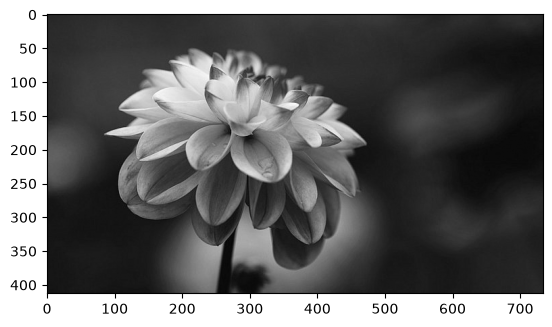

In [2]:
# Leer la imagen; el 0 indica que se carga en escala de grises
# img_gray = cv2.imread('/content/imagen.jpg', 0)  # Carga en entorno de Google Colab
img_gray = cv2.imread("imagen.jpg", 0)
# Visualizar la imagen
# cv2_imshow(img_gray)  # Para uso con Google Colab
plt.imshow(img_gray, cmap='gray')  # Para uso con matplotlib

In [3]:
print(f"La imagen monocromática es una matriz de dimensiones: {img_gray.shape}")
print(f"La matriz de la imagen se ve: \n {img_gray}")

La imagen monocromática es una matriz de dimensiones: (413, 734)
La matriz de la imagen se ve: 
 [[42 41 41 ... 41 42 41]
 [41 41 41 ... 41 41 41]
 [40 40 40 ... 41 41 41]
 ...
 [21 21 21 ... 40 39 39]
 [20 20 20 ... 40 40 39]
 [20 19 19 ... 41 40 40]]


Se observa que es una matriz de diversos números que representan la intensidad en las distintas filas y columnas. A continuación, se imprime y grafica una porción de esos píxeles.

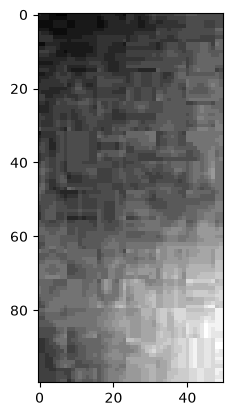

La imagen recortada es una matriz de dimensiones: (100, 50)
La matriz recortada se ve: 
 [[42 41 41 ... 45 45 45]
 [41 41 41 ... 45 45 45]
 [40 40 40 ... 44 45 45]
 ...
 [44 44 44 ... 56 58 57]
 [44 44 44 ... 56 57 57]
 [44 44 44 ... 56 58 58]]


In [4]:
# Se toma una porción de la imagen: filas de 0 a 100 y columnas de 0 a 50
img_recorte = img_gray[0:100, 0:50]
# Se crea una figura en matplotlib
plt.figure()
# Las imágenes monocromáticas se deben visualizar en matplotlib con el mapa de color gris
plt.imshow(img_recorte, cmap="gray")
plt.show()
print(f'La imagen recortada es una matriz de dimensiones: {img_recorte.shape}')
print(f'La matriz recortada se ve: \n {img_recorte}')

En las imágenes digitales típicas, cada píxel consta de un número entero de 8 bits, lo que genera 256 estados posibles: en la matriz se encuentran números de 0 a 255, y su tipo de dato es <code>uint8</code>.

In [5]:
print(f'Tipo de datos de la imagen: {img_gray.dtype}')

Tipo de datos de la imagen: uint8


![2 elevado a la 8 es igual a 256](assets/cv-img-04.png)

Las imágenes a color tienen, para cada píxel, tres números. En el espacio de color RGB — el más usado — cada número representa la intensidad del rojo (Red), verde (Green) y azul (Blue) que componen ese píxel. A estos se les llama canales.

![Herramienta "Digital Color Meter" leyendo el valor RGB de un píxel negro (0,0,0) y uno verde (3,168,124)](assets/cv-img-05.png)

*Con una herramienta de este tipo se puede leer, píxel por píxel, el valor RGB exacto que almacena una imagen a color.*

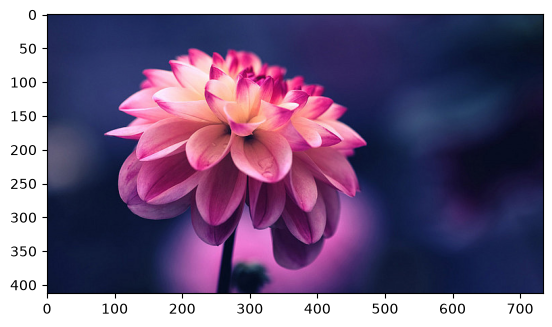

In [6]:
# img = cv2.imread("/content/imagen.jpg")
img = cv2.imread("imagen.jpg")

# cv2_imshow(img)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

In [7]:
print('Ahora la matriz tiene una tercera dimensión, que indica que la imagen cuenta con 3 canales:')
print(img.shape)

Ahora la matriz tiene una tercera dimensión, que indica que la imagen cuenta con 3 canales:
(413, 734, 3)


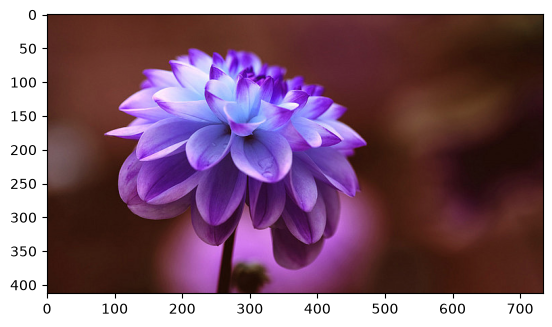

In [8]:
# Graficar la imagen con matplotlib
plt.figure()
plt.imshow(img)
plt.show()

La librería OpenCV tiene invertidos los canales azul y rojo — es decir, sus imágenes son BGR y no RGB —, por lo que, para visualizarlas correctamente con cualquier otra librería, es necesario convertirlas de BGR a RGB.

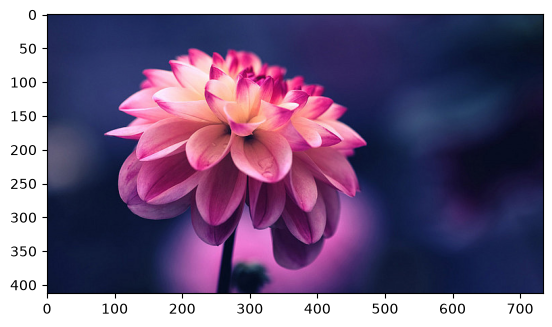

In [9]:
img_RGB = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Conversión de BGR a RGB
plt.figure()
plt.imshow(img_RGB)
plt.show()

A continuación, se examina el mismo recorte que se hizo sobre la imagen monocromática.

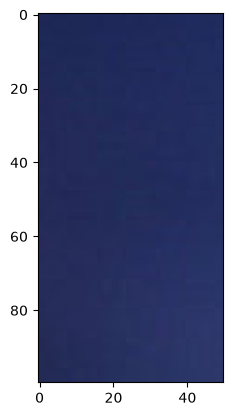

La imagen recortada es una matriz de dimensiones: (100, 50, 3)
La matriz recortada se ve: 
 [[[ 32  40  87]
  [ 31  39  86]
  [ 31  39  86]
  ...
  [ 31  43  93]
  [ 30  44  93]
  [ 30  44  93]]

 [[ 31  39  86]
  [ 31  39  86]
  [ 31  39  86]
  ...
  [ 31  43  93]
  [ 30  44  93]
  [ 30  44  93]]

 [[ 30  38  85]
  [ 30  38  85]
  [ 30  38  85]
  ...
  [ 30  42  92]
  [ 31  43  93]
  [ 31  43  93]]

 ...

 [[ 35  42  84]
  [ 35  42  84]
  [ 35  42  86]
  ...
  [ 44  54 105]
  [ 46  56 107]
  [ 45  55 106]]

 [[ 35  42  84]
  [ 35  42  84]
  [ 35  42  86]
  ...
  [ 44  54 105]
  [ 45  55 106]
  [ 45  55 106]]

 [[ 35  42  84]
  [ 35  42  84]
  [ 35  42  86]
  ...
  [ 44  54 105]
  [ 46  56 107]
  [ 46  56 107]]]


In [10]:
# Se toma una porción de la imagen: filas de 0 a 100 y columnas de 0 a 50
img_rgb_recorte = img_RGB[0:100, 0:50]
# Se crea una figura en matplotlib
plt.figure()
plt.imshow(img_rgb_recorte)
plt.show()
print(f'La imagen recortada es una matriz de dimensiones: {img_rgb_recorte.shape}')
print(f'La matriz recortada se ve: \n {img_rgb_recorte}')

Cada píxel está compuesto por tres números. A continuación, se examina el primer píxel (0,0) para comprobarlo.

In [11]:
print(img_RGB[0, 0])

[32 40 87]


Para extraer un canal específico, se agrega a las coordenadas un tercer índice que indica el canal deseado (0 = rojo, 1 = verde, 2 = azul).

In [12]:
print(f'Color rojo de la coordenada (0,0): {img_RGB[0, 0, 0]}')
print(f'Color verde de la coordenada (0,0): {img_RGB[0, 0, 1]}')
print(f'Color azul de la coordenada (0,0): {img_RGB[0, 0, 2]}')

Color rojo de la coordenada (0,0): 32
Color verde de la coordenada (0,0): 40
Color azul de la coordenada (0,0): 87


<a id="filtrado"></a>

## <span style="color:#F97066;">Filtrado de imágenes</span>

El filtrado de imágenes, en el contexto de la visión por computadora, se refiere a un proceso de modificar o mejorar una imagen aplicando un algoritmo específico o un conjunto de operaciones matemáticas a sus píxeles. El objetivo es manipular la imagen de tal manera que ciertas características se vuelvan más prominentes, lo que facilita la extracción de información relevante o la mejora de la calidad general de la imagen.

Los filtros de imagen suelen estar representados por una pequeña matriz o kernel, que se desliza sobre toda la imagen.

![Diagrama de convolución: una imagen de entrada multiplicada por un filtro produce una imagen de salida](assets/cv-img-06.png)

*El kernel (filtro) se superpone sobre una región de la imagen de entrada; la suma ponderada de esa región produce un único valor de la imagen de salida.*

Para filtrado lineal, la respuesta es dada por la suma de productos de los coeficientes del filtro y los correspondientes píxeles directamente bajo el kernel. A esta operación se le conoce como convolución.

En esencia, la convolución implica combinar dos funciones para producir una tercera función. En el procesamiento de imágenes, una de estas funciones es la imagen de entrada y la otra es una matriz más pequeña llamada núcleo o filtro. El kernel contiene valores numéricos que definen el comportamiento del filtro. El proceso implica deslizar el núcleo sobre la imagen, multiplicar sus valores con los valores de píxeles correspondientes en la imagen y sumar los resultados. Luego, esta suma se coloca en una ubicación específica de la imagen de salida.

En el contexto de la **convolución 1D**, la entrada consta de una matriz unidimensional, a menudo denominada vector de características.

![Diagrama de convolución 1D](assets/cv-img-07.png)

Se observa que esta operación produce una salida más pequeña que la imagen original. Para evitarlo, se aplica *padding* (relleno): agregar valores en los bordes de la matriz original para que el kernel tenga con qué operar y la imagen resultante conserve el tamaño de la original.

![Diagrama de convolución 1D con padding](assets/cv-img-08.png)

Para la convolución 2D el procedimiento es el mismo: el resultado se ubica en la posición donde estaría el centro del filtro en el momento de la operación.

![Diagrama de convolución 2D](assets/cv-img-09.png)

**Ejemplo:** una imagen en escala de grises de 8 bits, con una cuadrícula de 5×5. Los valores oscilan entre 0 y 255.

![Cuadrícula de 5x5 con valores de intensidad](assets/cv-img-10.png)

A continuación, un kernel aleatorio de 3×3:

![Kernel de 3x3](assets/cv-img-11.png)

Al aplicar el kernel sobre la entrada:

```
(-1×170) + (0×245) + (1×0) + (2×234) + (1×42) + (2×64) + (1×32) + (-2×53) + (0×128) = 394
```

![Resultado de la convolución colocado en la posición central](assets/cv-img-12.png)

Se reemplaza el píxel central con el valor calculado. Luego, se desplaza el kernel una posición a la vez (de arriba a la izquierda hacia abajo a la derecha) y se repiten los cálculos. Se usa relleno nuevamente para los píxeles del borde.

![Kernel desplazándose sobre la cuadrícula](assets/cv-img-13.png)

### <span style="color:#F97066;">Filtros</span>

La versatilidad de los filtros de imágenes cobra vida a través de su variedad de operaciones. Cada operación tiene un propósito distinto, ya sea moldear la estética de la imagen o facilitar un análisis más profundo:

- Filtros de suavizado.
- Filtros de afilado (*sharpening*).
- Filtros de mejora de bordes.

**Filtro de suavizado (*blurring*)**

Consiste en reemplazar el valor de un píxel por el promedio de los niveles de gris de sus vecinos, lo que reduce las transiciones abruptas o muy marcadas entre niveles de gris.

Este tipo de transiciones fuertes ("*sharp*") se debe principalmente a dos causas:

- Ruido aleatorio en la imagen (por su naturaleza de cambios bruscos entre niveles de gris).
- Los bordes de los objetos en la imagen, que también se caracterizan por transiciones abruptas de intensidad.

Por lo tanto, el suavizado reduce el ruido (deseable) pero también difumina los bordes (indeseable).

![Ejemplo de filtro de suavizado](assets/cv-img-14.png)

El promedio ponderado según la distancia al centro del kernel corresponde al filtro gaussiano.

![Kernel gaussiano](assets/cv-img-15.png)

La extracción de bordes o *sharpening* busca el efecto opuesto al suavizado: resaltar las discontinuidades (bordes) en lugar de atenuarlas.

![Ejemplo de filtro de afilado](assets/cv-img-16.png)

![Kernel de afilado](assets/cv-img-17.png)

**Filtros laplacianos**

![Kernel laplaciano](assets/cv-img-18.png)

En OpenCV, la convolución se realiza con la función <code>cv2.filter2D</code>.

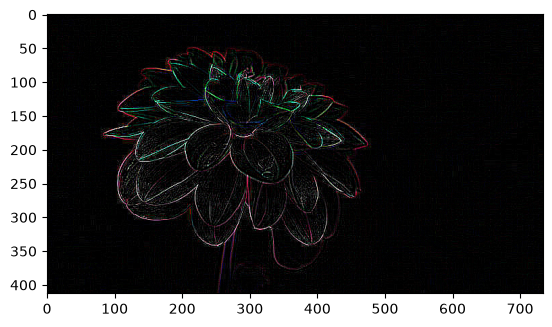

In [13]:
# Convolución en imagen a color
# Matriz de kernel laplaciano
kernel = np.array([[1, 1, 1],
                    [1, -8, 1],
                    [1, 1, 1]])
# Convolución entre la imagen y el kernel. El segundo argumento es 'ddepth' (profundidad/tipo de dato
# de la imagen de salida); -1 significa 'igual profundidad que la imagen de entrada'. OpenCV aplica el
# kernel a cada canal automáticamente, sin importar el valor de ddepth.
convolucion = cv2.filter2D(img_RGB, -1, kernel)
plt.figure()
plt.imshow(convolucion)
plt.show()

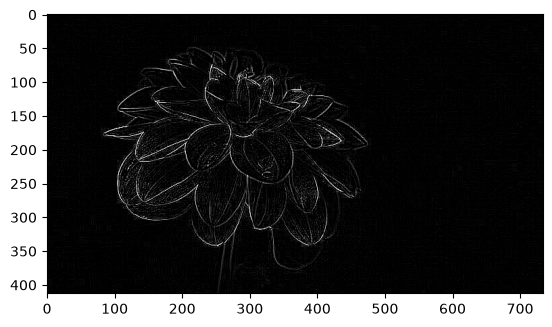

In [14]:
# Convolución en escala de grises
kernel = np.array([[1, 1, 1],
                    [1, -8, 1],
                    [1, 1, 1]])
convolucion = cv2.filter2D(img_gray, -1, kernel)
plt.figure()
plt.imshow(convolucion, cmap="gray")
plt.show()

<a id="deteccion-bordes"></a>

## <span style="color:#F97066;">Detección de bordes: Sobel y Canny</span>

El filtro laplaciano de la sección anterior ya resalta bordes, pero es sensible al ruido porque combina la variación de intensidad en todas las direcciones a la vez. El operador de **Sobel** sigue exactamente el mismo mecanismo de convolución visto hasta ahora, solo que usa dos kernels distintos — diseñados para aproximar la derivada de la imagen — uno para detectar cambios de intensidad horizontales y otro para cambios verticales.

<div style="border-left:4px solid #6366F1; background:rgba(99,102,241,0.08); border-radius:6px; padding:10px 16px; margin:16px 0;">
<strong>📝 Nota</strong><br>
El resultado de Sobel se calcula en <code>CV_64F</code> (números de punto flotante con signo) en lugar de <code>uint8</code>, porque un borde puede producir gradientes negativos (de claro a oscuro). Si se usara <code>uint8</code> directamente, esos valores negativos se recortarían a 0 y se perderían bordes reales.
</div>

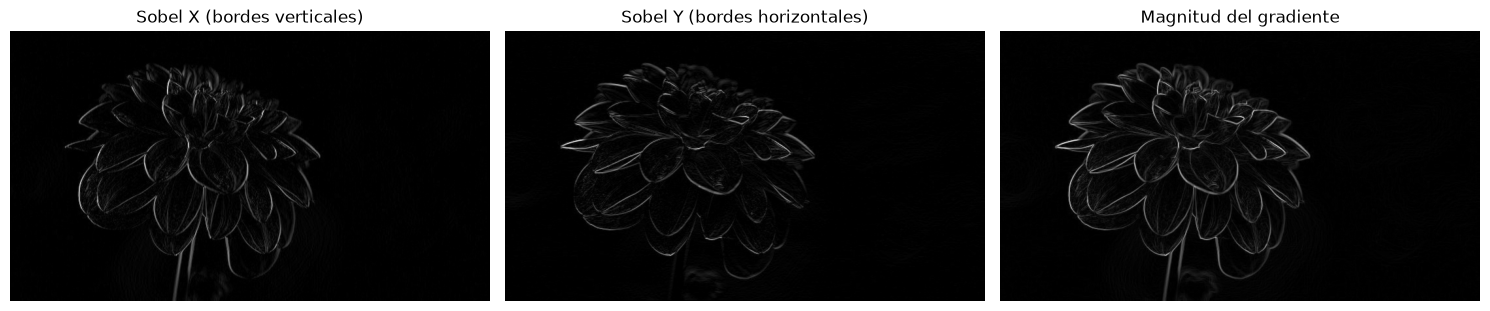

Magnitud del gradiente: mínimo=0.0, máximo=847.7


In [15]:
# 1. Gradiente en x (bordes verticales) y en y (bordes horizontales)
sobel_x = cv2.Sobel(img_gray, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(img_gray, cv2.CV_64F, 0, 1, ksize=3)

# 2. Magnitud del gradiente: combina ambas direcciones en una sola medida de "qué tan fuerte es el borde"
sobel_mag = np.sqrt(sobel_x**2 + sobel_y**2)

# 3. Visualización de las tres versiones
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(np.abs(sobel_x), cmap="gray")
axes[0].set_title("Sobel X (bordes verticales)")
axes[1].imshow(np.abs(sobel_y), cmap="gray")
axes[1].set_title("Sobel Y (bordes horizontales)")
axes[2].imshow(sobel_mag, cmap="gray")
axes[2].set_title("Magnitud del gradiente")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

print(f"Magnitud del gradiente: mínimo={sobel_mag.min():.1f}, máximo={sobel_mag.max():.1f}")

**Canny** es un algoritmo de detección de bordes más completo, que internamente también calcula gradientes tipo Sobel, pero además aplica varios pasos adicionales (suavizado previo, supresión de no-máximos y un doble umbral) para producir bordes delgados y continuos en lugar de una imagen de magnitud "difusa" como la anterior. Recibe dos umbrales: por debajo del menor, un píxel no se considera borde; por encima del mayor, sí se considera borde; entre ambos, solo se considera borde si está conectado a un borde ya confirmado.

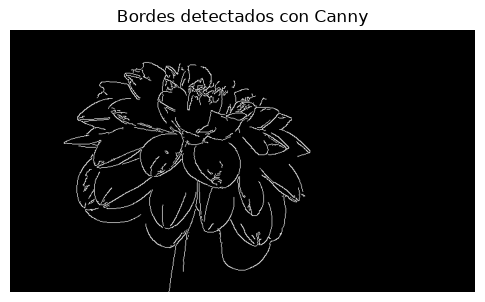

Porcentaje de píxeles clasificados como borde: 2.5%


In [16]:
# Detección de bordes con Canny (umbral inferior=100, umbral superior=200)
bordes_canny = cv2.Canny(img_gray, 100, 200)

plt.figure(figsize=(6, 4))
plt.imshow(bordes_canny, cmap="gray")
plt.title("Bordes detectados con Canny")
plt.axis("off")
plt.show()

fraccion_bordes = (bordes_canny > 0).mean()
print(f"Porcentaje de píxeles clasificados como borde: {fraccion_bordes:.1%}")

<a id="binarizacion"></a>

## <span style="color:#F97066;">Binarización y umbral de Otsu</span>

La forma más simple de segmentar una imagen (separar "objeto" de "fondo") es la **binarización**: convertir la imagen en escala de grises en una imagen de solo dos valores (0 o 255) a partir de un umbral de intensidad. Todo píxel por debajo del umbral se vuelve negro, y todo píxel igual o por encima se vuelve blanco.

La dificultad está en elegir el umbral. Un valor fijo, como 127 (la mitad del rango de 0 a 255), funciona solo si la imagen tiene, en promedio, aproximadamente la misma cantidad de zonas claras y oscuras — algo que rara vez se cumple. El **método de Otsu** elige el umbral automáticamente: analiza el histograma de intensidades de la imagen y busca el valor que mejor separa los píxeles en dos grupos (claro y oscuro), minimizando la dispersión dentro de cada grupo.

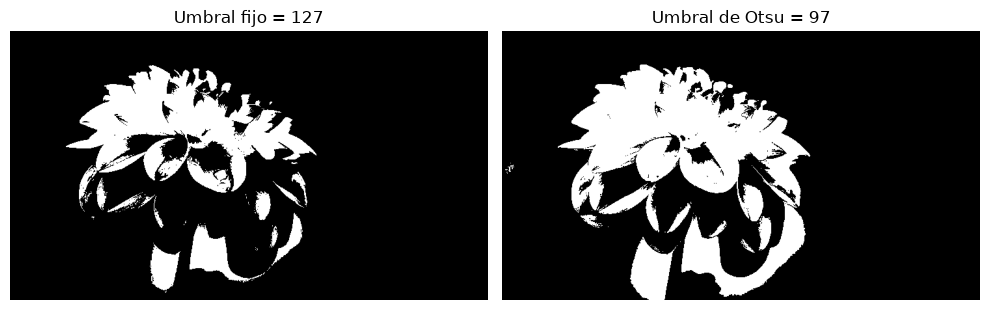

Umbral fijo (127): 13.5% de píxeles blancos
Umbral de Otsu (97): 20.6% de píxeles blancos


In [17]:
# 1. Umbral fijo en 127
_, binaria_fija = cv2.threshold(img_gray, 127, 255, cv2.THRESH_BINARY)

# 2. Umbral elegido automáticamente por el método de Otsu
umbral_otsu, binaria_otsu = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 3. Comparación visual
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(binaria_fija, cmap="gray")
axes[0].set_title("Umbral fijo = 127")
axes[1].imshow(binaria_otsu, cmap="gray")
axes[1].set_title(f"Umbral de Otsu = {umbral_otsu:.0f}")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

print(f"Umbral fijo (127): {(binaria_fija == 255).mean():.1%} de píxeles blancos")
print(f"Umbral de Otsu ({umbral_otsu:.0f}): {(binaria_otsu == 255).mean():.1%} de píxeles blancos")

<div style="border-left:4px solid #6366F1; background:rgba(99,102,241,0.08); border-radius:6px; padding:10px 16px; margin:16px 0;">
<strong>📝 Nota</strong><br>
Otsu elige el umbral a partir del histograma de la imagen completa, por lo que funciona bien cuando la imagen tiene una separación clara entre dos grupos de intensidad (por ejemplo, un objeto oscuro sobre un fondo claro). En imágenes con iluminación desigual o con más de dos grupos de intensidad, un único umbral global — fijo u Otsu — deja de ser suficiente, y se requieren técnicas de umbral adaptativo que calculan un umbral distinto para cada región de la imagen.
</div>

---

<a id="cierre"></a>

# <span style="color:#F97066;">🎯 Cierre y próximos pasos</span>

<div style="border-left:4px solid #14B8A6; background:rgba(20,184,166,0.08); border-radius:6px; padding:10px 16px; margin:16px 0;">
<strong>✅ Resumen</strong><br>
Este notebook presentó los fundamentos de la visión por computadora clásica:

- Representación de una imagen como una matriz de números: en escala de grises (un valor por píxel) y a color (tres canales, R-G-B).
- La convolución: deslizar un kernel sobre la imagen para producir una nueva imagen filtrada.
- Filtros de suavizado, de afilado (*sharpening*) y laplacianos.
- Detección de bordes con Sobel (gradiente por dirección) y Canny (bordes delgados y continuos).
- Binarización con un umbral fijo y con el umbral automático de Otsu.

</div>

<div style="border:1px solid rgba(14,165,233,0.35); border-radius:10px; padding:14px 20px; margin:16px 0; background:rgba(14,165,233,0.04);">
<strong>➡️ Continúe con</strong>
<ul style="margin:8px 0 0; padding-left:20px;">
<li><code>3-redes-convolucionales.ipynb</code> — usa exactamente la misma operación de convolución vista aquí: la diferencia es que, en una CNN, los valores del kernel ya no se definen a mano (como el laplaciano o el de Sobel), sino que se aprenden automáticamente durante el entrenamiento.</li>
</ul>
</div>